# CPI RNN model comparison

Run the requested recurrent models on `cpi_forecast_selected_variables.csv` with target `cpi_mom_inflation`, then compare validation/test forecast metrics.

In [80]:
from pathlib import Path
import importlib.util
import sys
import pandas as pd

MODULE_PATH = Path('rnn-models.py').resolve()
spec = importlib.util.spec_from_file_location('rnn_models', MODULE_PATH)
rnn_models = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = rnn_models
spec.loader.exec_module(rnn_models)


In [81]:
DATA_PATH = Path('../cpi_forecast_selected_variables.csv')
OUT_DIR = Path('rnn_results')

data_config = rnn_models.RNNDataConfig(
    date_col='date',
    target='cpi_mom_inflation',
    features=('broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND'),
    freq='MS',
    log_transform=False,
    stationarity=True,
    train_ratio=0.70,
    val_ratio=0.15,
)

COMMON_TRAIN_CONFIG = dict(
    time_steps=12,
    units=12,
    dense_units=6,
    dropout=0.1,
    learning_rate=1e-3,
    epochs=800,
    batch_size=16,
    patience=12,
    seed=7,
)

target_plus_features = (data_config.target, *data_config.features)
exog_only_features = data_config.features

model_runs = [
    {'label': 'LSTM(347,12,9)', 'model_type': 'LSTM', 'input_columns': target_plus_features},
    {'label': 'GRU(347,12,9)', 'model_type': 'GRU', 'input_columns': target_plus_features},
    {'label': 'GRU(347,12,8)', 'model_type': 'GRU', 'input_columns': exog_only_features},
]


Epoch 1/800


/home/hgiang/.local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 - 2s - 131ms/step - loss: 1.0453 - mda: 0.3685 - rmse: 0.6787 - val_loss: 0.3494 - val_mda: 0.4750 - val_rmse: 0.4423 - learning_rate: 0.0010
Epoch 2/800
15/15 - 0s - 8ms/step - loss: 0.9964 - mda: 0.4448 - rmse: 0.6498 - val_loss: 0.3310 - val_mda: 0.5333 - val_rmse: 0.4255 - learning_rate: 0.0010
Epoch 3/800
15/15 - 0s - 9ms/step - loss: 0.9774 - mda: 0.4930 - rmse: 0.6393 - val_loss: 0.3210 - val_mda: 0.6417 - val_rmse: 0.4170 - learning_rate: 0.0010
Epoch 4/800
15/15 - 0s - 8ms/step - loss: 0.9463 - mda: 0.5737 - rmse: 0.6217 - val_loss: 0.3150 - val_mda: 0.7000 - val_rmse: 0.4133 - learning_rate: 0.0010
Epoch 5/800
15/15 - 0s - 9ms/step - loss: 0.9455 - mda: 0.6092 - rmse: 0.6232 - val_loss: 0.3127 - val_mda: 0.6667 - val_rmse: 0.4126 - learning_rate: 0.0010
Epoch 6/800
15/15 - 0s - 9ms/step - loss: 0.9257 - mda: 0.5545 - rmse: 0.6192 - val_loss: 0.3113 - val_mda: 0.6500 - val_rmse: 0.4123 - learning_rate: 0.0010
Epoch 7/800
15/15 - 0s - 8ms/step - loss: 0.9174 - mda: 0.6639

/home/hgiang/.local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 - 2s - 154ms/step - loss: 1.0600 - mda: 0.5432 - rmse: 0.7115 - val_loss: 0.4019 - val_mda: 0.6000 - val_rmse: 0.4520 - learning_rate: 0.0010
Epoch 2/800
15/15 - 0s - 9ms/step - loss: 0.9556 - mda: 0.6085 - rmse: 0.6452 - val_loss: 0.3739 - val_mda: 0.6000 - val_rmse: 0.4361 - learning_rate: 0.0010
Epoch 3/800
15/15 - 0s - 10ms/step - loss: 0.9374 - mda: 0.6239 - rmse: 0.6414 - val_loss: 0.3553 - val_mda: 0.6167 - val_rmse: 0.4263 - learning_rate: 0.0010
Epoch 4/800
15/15 - 0s - 9ms/step - loss: 0.8596 - mda: 0.6150 - rmse: 0.6194 - val_loss: 0.3442 - val_mda: 0.6167 - val_rmse: 0.4216 - learning_rate: 0.0010
Epoch 5/800
15/15 - 0s - 11ms/step - loss: 0.9382 - mda: 0.6588 - rmse: 0.6238 - val_loss: 0.3301 - val_mda: 0.6583 - val_rmse: 0.4150 - learning_rate: 0.0010
Epoch 6/800
15/15 - 0s - 11ms/step - loss: 0.8362 - mda: 0.6270 - rmse: 0.6026 - val_loss: 0.3199 - val_mda: 0.6417 - val_rmse: 0.4094 - learning_rate: 0.0010
Epoch 7/800
15/15 - 0s - 13ms/step - loss: 0.8089 - mda: 0.

/home/hgiang/.local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 - 2s - 150ms/step - loss: 1.0225 - mda: 0.5921 - rmse: 0.6682 - val_loss: 0.3753 - val_mda: 0.5000 - val_rmse: 0.4465 - learning_rate: 0.0010
Epoch 2/800
15/15 - 0s - 9ms/step - loss: 0.9953 - mda: 0.5552 - rmse: 0.6472 - val_loss: 0.3540 - val_mda: 0.5500 - val_rmse: 0.4279 - learning_rate: 0.0010
Epoch 3/800
15/15 - 0s - 10ms/step - loss: 0.9937 - mda: 0.5292 - rmse: 0.6387 - val_loss: 0.3398 - val_mda: 0.5500 - val_rmse: 0.4161 - learning_rate: 0.0010
Epoch 4/800
15/15 - 0s - 9ms/step - loss: 0.9783 - mda: 0.5528 - rmse: 0.6288 - val_loss: 0.3319 - val_mda: 0.5500 - val_rmse: 0.4105 - learning_rate: 0.0010
Epoch 5/800
15/15 - 0s - 10ms/step - loss: 0.9679 - mda: 0.5826 - rmse: 0.6246 - val_loss: 0.3288 - val_mda: 0.5333 - val_rmse: 0.4094 - learning_rate: 0.0010
Epoch 6/800
15/15 - 0s - 10ms/step - loss: 0.9712 - mda: 0.5197 - rmse: 0.6273 - val_loss: 0.3289 - val_mda: 0.5500 - val_rmse: 0.4107 - learning_rate: 0.0010
Epoch 7/800
15/15 - 0s - 10ms/step - loss: 0.9723 - mda: 0.

,model,input_shape,input_columns,split,scale,RMSE,MAE,MAPE
0,"LSTM(347,12,9)","(347, 12, 9)","cpi_mom_inflation,broad_money,ppi_qoq,wti,gold...",validation,raw_transformed,0.713398,0.526533,122.997282
1,"LSTM(347,12,9)","(347, 12, 9)","cpi_mom_inflation,broad_money,ppi_qoq,wti,gold...",test,raw_transformed,0.852943,0.649798,145.946605
2,"GRU(347,12,9)","(347, 12, 9)","cpi_mom_inflation,broad_money,ppi_qoq,wti,gold...",validation,raw_transformed,0.670377,0.505660,236.138867
3,"GRU(347,12,9)","(347, 12, 9)","cpi_mom_inflation,broad_money,ppi_qoq,wti,gold...",test,raw_transformed,0.831360,0.632036,206.961944
4,"GRU(347,12,8)","(347, 12, 8)","broad_money,ppi_qoq,wti,gold,policy_rate,VNIND...",validation,raw_transformed,0.740041,0.528344,160.568018
5,"GRU(347,12,8)","(347, 12, 8)","broad_money,ppi_qoq,wti,gold,policy_rate,VNIND...",test,raw_transformed,0.886310,0.637241,121.248359


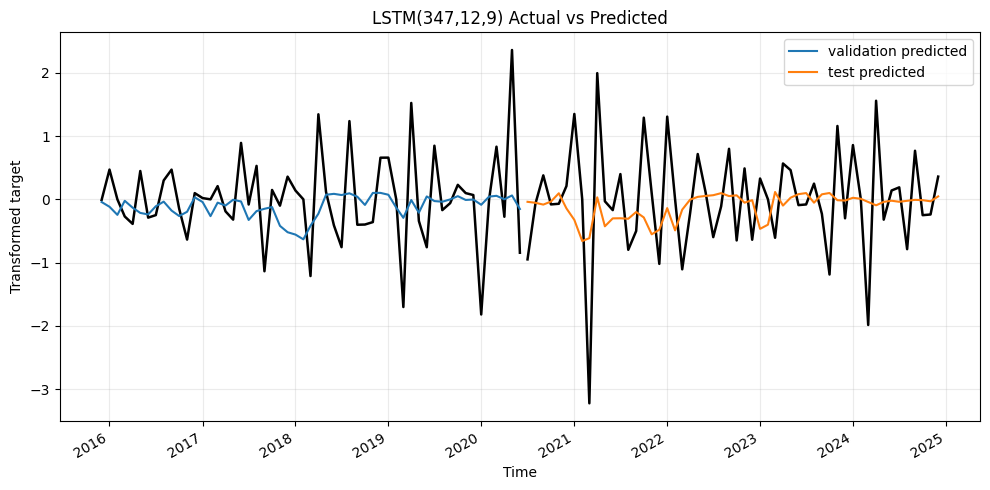

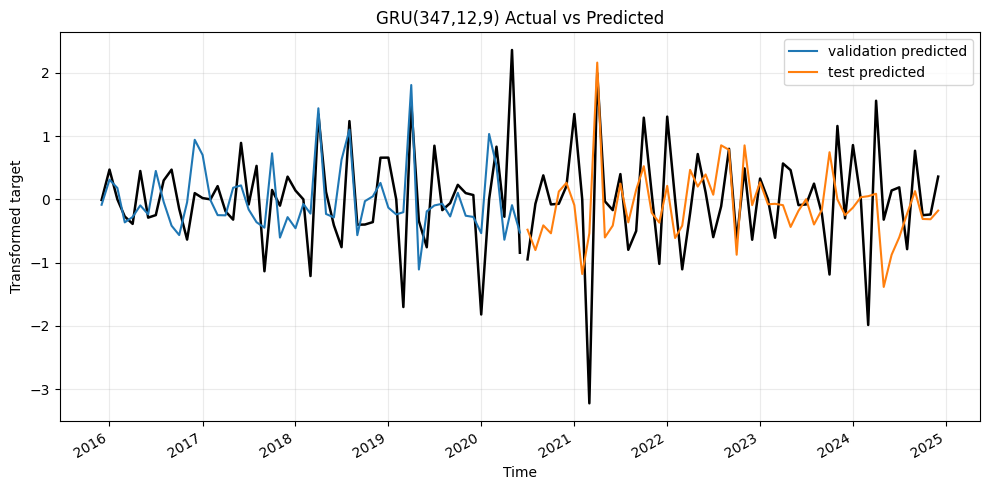

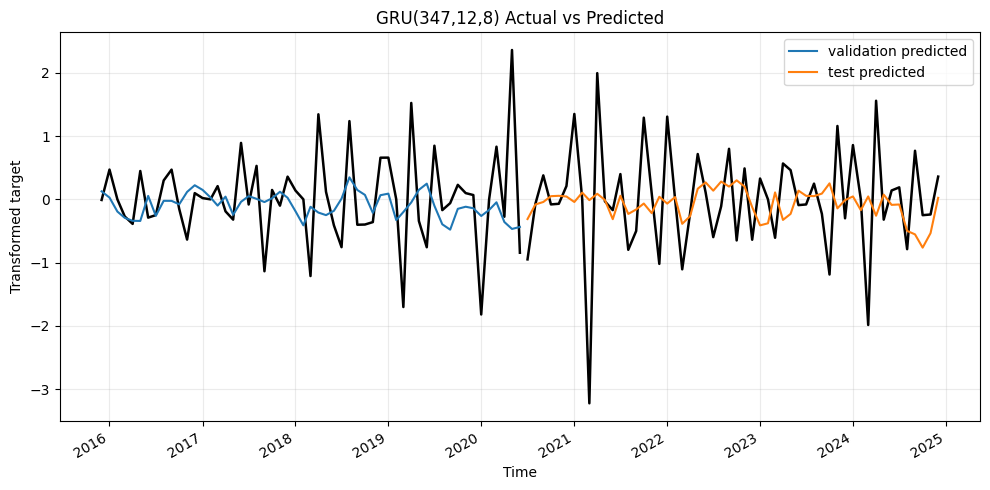

In [82]:
results = {}
comparison_rows = []
shape_rows = []

for run in model_runs:
    train_config = rnn_models.RNNTrainConfig(
        model_type=run['model_type'],
        model_label=run['label'],
        **COMMON_TRAIN_CONFIG,
    )
    result = rnn_models.run_rnn_comparison(
        DATA_PATH,
        OUT_DIR,
        data_config,
        train_config,
        input_columns=run['input_columns'],
    )
    results[run['label']] = result
    comparison_rows.append(result['metrics'])
    shape_rows.append(result['input_shape'])

comparison_table = pd.concat(comparison_rows, ignore_index=True)
input_shape_table = pd.concat(shape_rows, ignore_index=True)
comparison_table


In [83]:
input_shape_table


,model,input_shape,train_shape,validation_shape,test_shape,input_columns
0,"LSTM(347,12,9)","(347, 12, 9)","(238, 12, 9)","(55, 12, 9)","(54, 12, 9)","[cpi_mom_inflation, broad_money, ppi_qoq, wti,..."
1,"GRU(347,12,9)","(347, 12, 9)","(238, 12, 9)","(55, 12, 9)","(54, 12, 9)","[cpi_mom_inflation, broad_money, ppi_qoq, wti,..."
2,"GRU(347,12,8)","(347, 12, 8)","(238, 12, 8)","(55, 12, 8)","(54, 12, 8)","[broad_money, ppi_qoq, wti, gold, policy_rate,..."


In [84]:
comparison_wide = comparison_table.pivot(index='model', columns='split', values=['RMSE', 'MAE', 'MAPE'])
comparison_wide.columns = [f'{metric}_{split}' for metric, split in comparison_wide.columns]
comparison_wide = comparison_wide.reset_index().sort_values('RMSE_test')
comparison_wide


,model,RMSE_test,RMSE_validation,MAE_test,MAE_validation,MAPE_test,MAPE_validation
1,"GRU(347,12,9)",0.831360,0.670377,0.632036,0.505660,206.961944,236.138867
2,"LSTM(347,12,9)",0.852943,0.713398,0.649798,0.526533,145.946605,122.997282
0,"GRU(347,12,8)",0.886310,0.740041,0.637241,0.528344,121.248359,160.568018


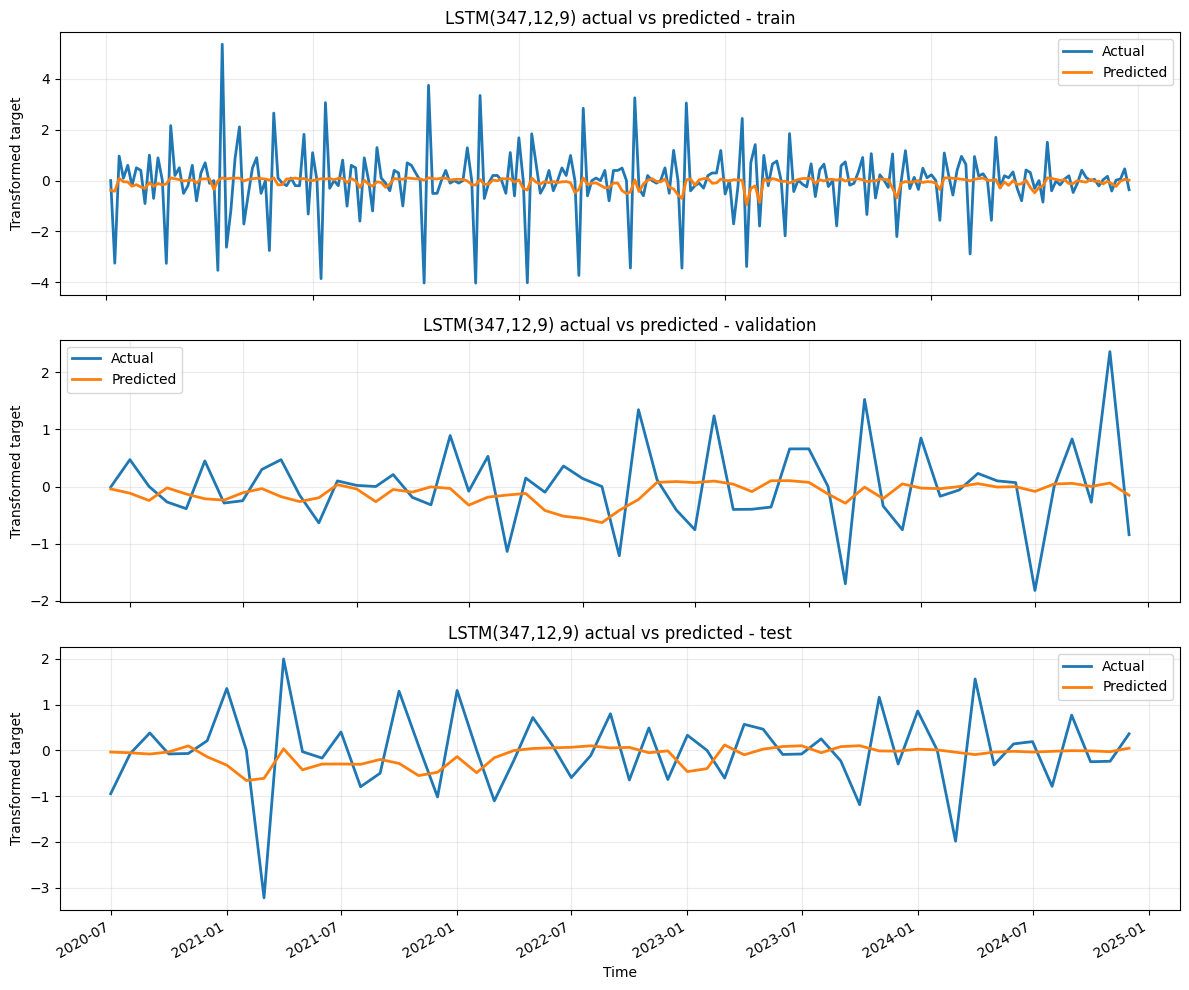

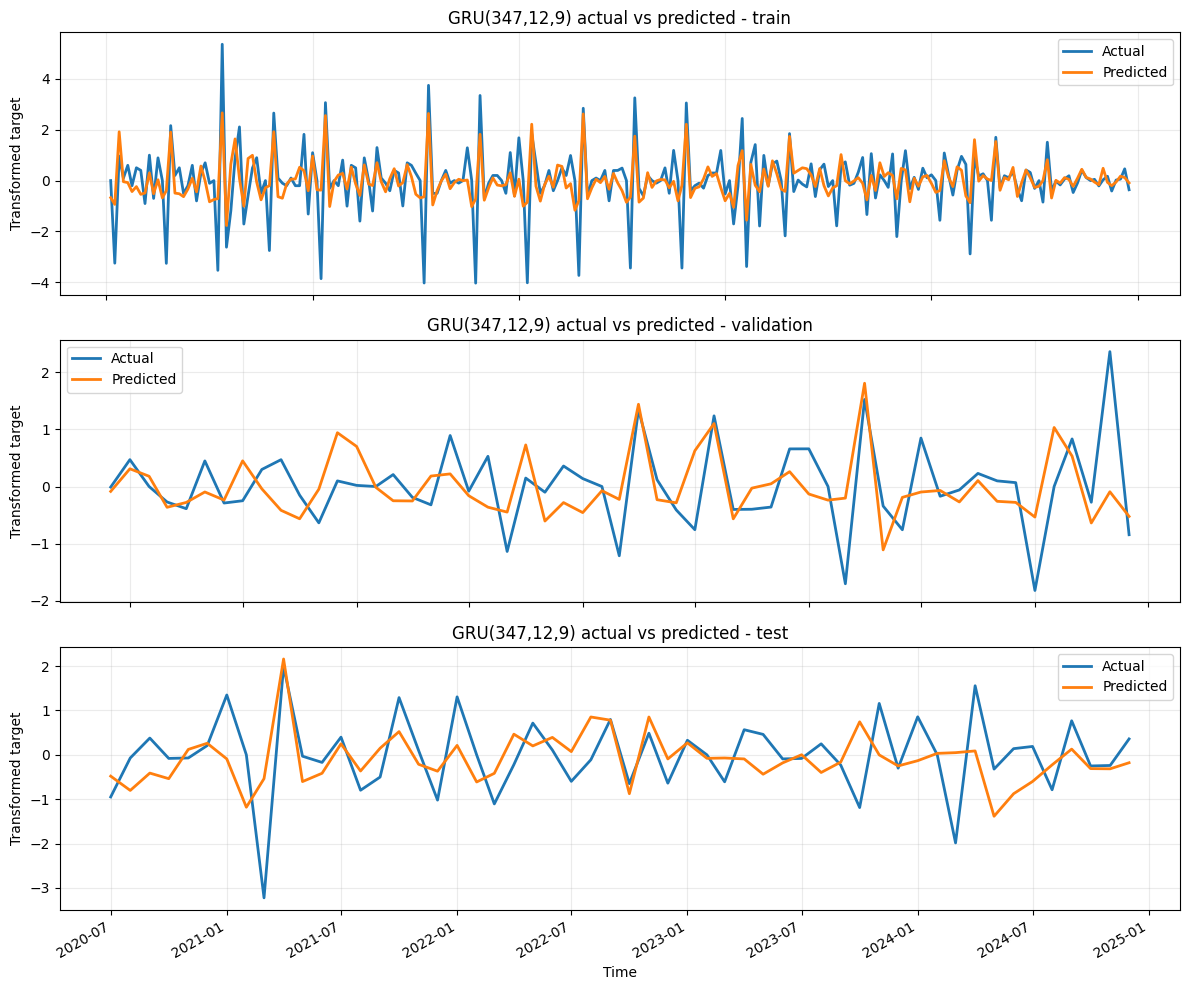

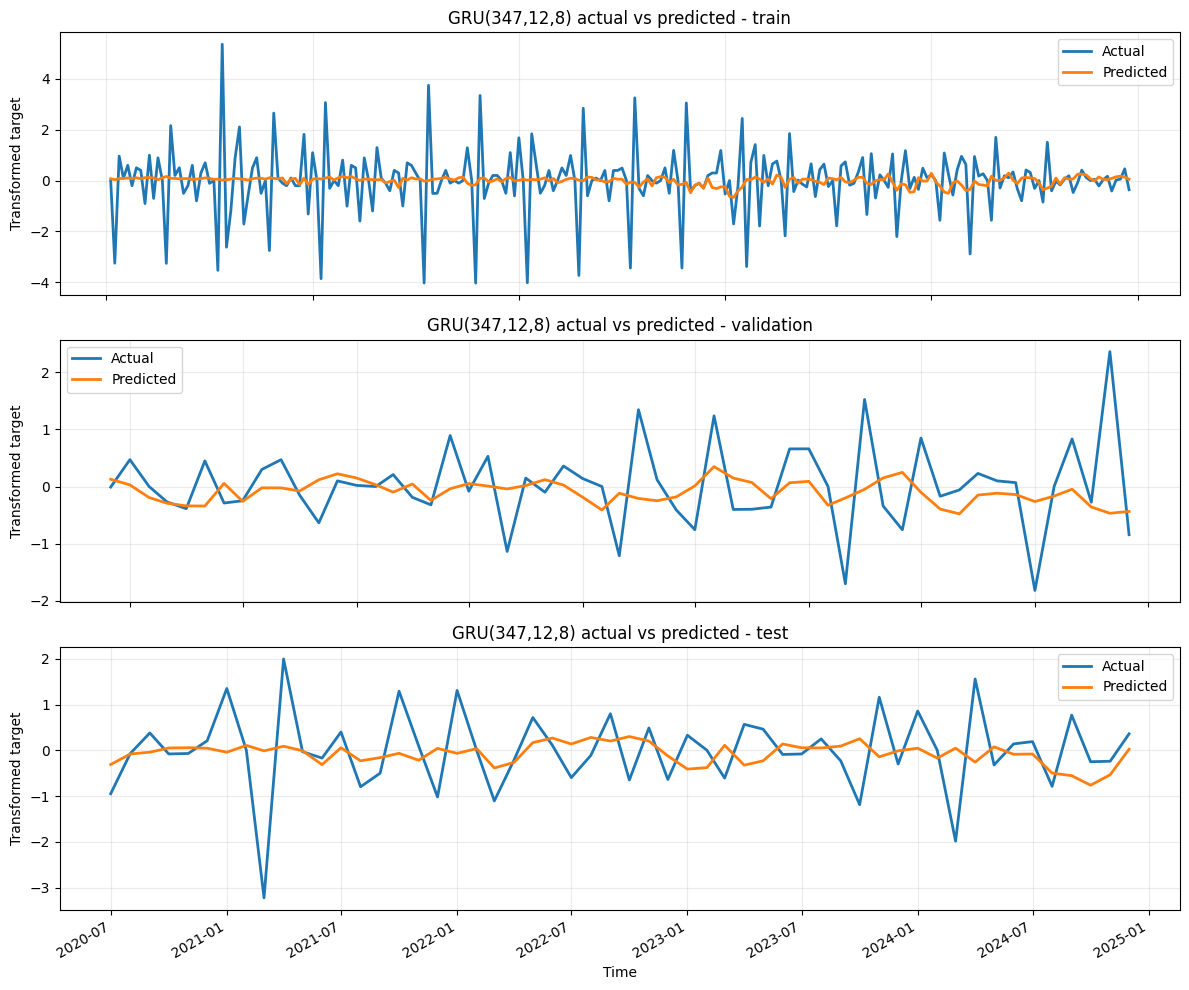

In [85]:
import matplotlib.pyplot as plt

split_order = ['train', 'validation', 'test']

for label, result in results.items():
    plot_df = result['predictions'].copy()
    plot_df['date'] = pd.to_datetime(plot_df['date'])
    fig, axes = plt.subplots(len(split_order), 1, figsize=(12, 10), sharex=False)
    for ax, split in zip(axes, split_order):
        split_df = plot_df[plot_df['split'].eq(split)].sort_values('date')
        ax.plot(split_df['date'], split_df['actual_raw_transformed'], label='Actual', linewidth=2)
        ax.plot(split_df['date'], split_df['predicted_raw_transformed'], label='Predicted', linewidth=2)
        ax.set_title(f'{label} actual vs predicted - {split}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Transformed target')
        ax.grid(True, alpha=0.25)
        ax.legend()

    fig.autofmt_xdate()
    fig.tight_layout()
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    file_stem = label.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '_')
    fig.savefig(OUT_DIR / f'{file_stem}_actual_vs_predicted_train_val_test.png', dpi=160)
    plt.show()


In [86]:
next(iter(results.values()))['stationarity_screen']


,Variable,ADF level p,KPSS level p,ADF diff1 p,KPSS diff1 p,Transform used,Decision basis
0,cpi_mom_inflation,NaN,NaN,NaN,NaN,diff1,train_only
1,broad_money,NaN,NaN,NaN,NaN,diff1,train_only
2,ppi_qoq,NaN,NaN,NaN,NaN,diff1,train_only
3,wti,NaN,NaN,NaN,NaN,diff1,train_only
4,gold,NaN,NaN,NaN,NaN,diff1,train_only
5,policy_rate,NaN,NaN,NaN,NaN,diff1,train_only
6,VNINDEX,NaN,NaN,NaN,NaN,diff1,train_only
7,NIKKEI225,NaN,NaN,NaN,NaN,diff1,train_only
8,USDVND,NaN,NaN,NaN,NaN,diff1,train_only
